In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import Gaussian2DKernel, Box1DKernel, convolve, convolve_fft
import astropy.constants as const
import astropy.units as u
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit


In [2]:
def makegauss(v, amp,vcen,fwhm): # unit, km/s, km/s
    sig = 1./(2.*np.sqrt(2*np.log(2)))*fwhm
    y = np.exp(-(v-vcen)**2./(2*sig**2))*amp
    return v,y

In [3]:
makegauss(np.arange(-10,10,1), 1,0,1)

(array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9]),
 array([3.87259191e-121, 2.92604772e-098, 8.63616856e-078, 9.95682444e-060,
        4.48415509e-044, 7.88860905e-031, 5.42101086e-020, 1.45519152e-011,
        1.52587891e-005, 6.25000000e-002, 1.00000000e+000, 6.25000000e-002,
        1.52587891e-005, 1.45519152e-011, 5.42101086e-020, 7.88860905e-031,
        4.48415509e-044, 9.95682444e-060, 8.63616856e-078, 2.92604772e-098]))

In [4]:
def makegaussfit(v, amp,vcen,fwhm ): # unit, km/s, km/s
    sig = 1./(2.*np.sqrt(2*np.log(2)))*fwhm
    y = np.exp(-(v-vcen)**2./(2*sig**2))*amp
    return y
def mygaussfit(x,y):
    popt, pcov = curve_fit(makegaussfit, x, y, p0 = [1,0,20])
    return popt

In [5]:
def lnprior1(para,est):
    for _para, _est in zip(para,est):
        if not (_est[1]<_para<_est[2]):
            return -np.inf
    return 0.0

In [6]:
def log_prob(para, obs,est, plot=False,vmin=None,vmax=None):
    y1 = []
    y2 = []
    y3 = []
    y4 = []
    for i in range(len(para)//6):
        _,_y1 = makegauss(obs[0][0],para[2+i*6],para[0+i*6],para[1+i*6])
        y1.append(_y1)
        _,_y2 = makegauss(obs[1][0],para[3+i*6],para[0+i*6],para[1+i*6])
        y2.append(_y2)
        _,_y3 = makegauss(obs[2][0],para[4+i*6],para[0+i*6],para[1+i*6])
        y3.append(_y3)
        _,_y4 = makegauss(obs[3][0],para[5+i*6],para[0+i*6],para[1+i*6])
        y4.append(_y4)
    
    #1612
    y1mod = np.sum(np.array(y1),axis=0)
    #1665
    y2mod = np.sum(np.array(y2),axis=0)
    #1667
    y3mod = np.sum(np.array(y3),axis=0)
    #1720
    y4mod = np.sum(np.array(y4),axis=0)
    # collect all models
    mod = [y1mod,y2mod,y3mod,y4mod]

    #plot
    if plot:
        plt.close('all')
        fig,ax = plt.subplots(4,1,figsize=(8,16),sharex=True,sharey=True)
        for i,(_out,_obs) in enumerate(zip(mod,obs)):
            ax[i].step(_obs[0], _obs[1],where='mid', color='black')
            ax[i].step(_obs[0], 3.*_obs[2],where='mid', color='gray')
            ax[i].step(_obs[0], -3.*_obs[2],where='mid', color='gray')
            ax[i].plot(_obs[0], _out,color='red',label=str(i))
            ax[i].set_xlim([vmin,vmax])
            ax[i].legend()


    # interpolate to different frequencies
    logprob = []
    for _obs,_mod in zip(obs,mod):
        # calculate log probability
        logprob.append(np.sum(-0.5*(((_obs[1]-_mod)/_obs[2])**2.+np.log(np.median(_obs[2])))))
        # return sum
    return np.array(logprob).sum()+lnprior1(para,est)  if np.isfinite(np.array(logprob).sum()) else -np.inf


In [7]:
# create mock data
def makeobs(v,rms,in_para):
    y1 = []
    y2 = []
    y3 = []
    y4 = []
    for _in_para in in_para:
        #1612
        _,_y1 = makegauss(v,_in_para[2],_in_para[0],_in_para[1])
        y1.append(_y1)
        _,_y2 = makegauss(v,_in_para[3],_in_para[0],_in_para[1])
        y2.append(_y2)
        _,_y3 = makegauss(v,_in_para[4],_in_para[0],_in_para[1])
        y3.append(_y3)
        _,_y4 = makegauss(v,_in_para[5],_in_para[0],_in_para[1])
        y4.append(_y4)
    
    #1612
    y1obs = np.sum(np.array(y1),axis=0)+np.random.normal(0,1,len(v))*rms
    rms1 = np.ones_like(v)*rms
    #1665
    y2obs = np.sum(np.array(y2),axis=0)+np.random.normal(0,1,len(v))*rms
    rms2 = np.ones_like(v)*rms
    #1667
    y3obs = np.sum(np.array(y3),axis=0)+np.random.normal(0,1,len(v))*rms
    rms3 = np.ones_like(v)*rms
    #1720
    y4obs = np.sum(np.array(y4),axis=0)+np.random.normal(0,1,len(v))*rms
    rms4 = np.ones_like(v)*rms
    
    # collect all modelled observations
    obs = [[v,y1obs,rms1],[v,y2obs,rms2],[v,y3obs,rms3],[v,y4obs,rms4]]

    # plot
    plt.close('all')
    for i,_out in enumerate(obs):
        plt.step(_out[0], _out[1],where='mid', label=str(i))
    plt.xlim([-10,10])
    plt.legend()
    
    # return
    return obs
    

### Noise properties

In [8]:
rms=0.02
v=np.arange(-50,50,.2)



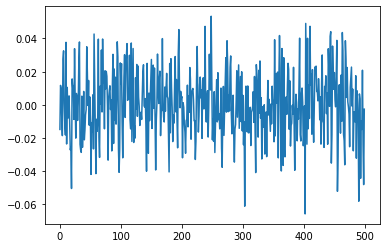

In [9]:
plt.plot(np.random.normal(0,1,len(v))*rms)

(array([  7.,  12.,  40.,  81., 128., 110.,  74.,  37.,   8.,   3.]),
 array([-0.06142485, -0.04880563, -0.0361864 , -0.02356718, -0.01094795,
         0.00167127,  0.0142905 ,  0.02690972,  0.03952895,  0.05214817,
         0.0647674 ]),
 <BarContainer object of 10 artists>)

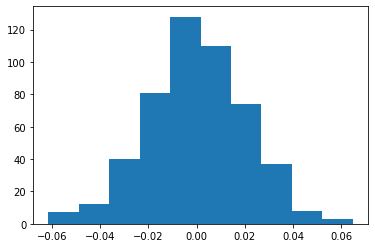

In [10]:
plt.hist(np.random.normal(0,1,len(v))*rms)

## Make Line

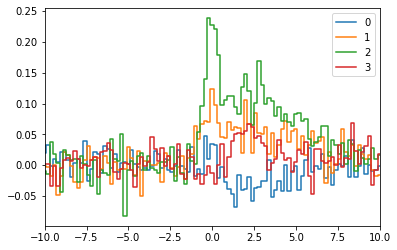

In [11]:
inputpara = [[0.,1.,0.03,0.1,0.2,-0.03],[2.,3.,-0.04,0.05,0.1,0.04],[5.,5.,-0.01,0.03,0.06,0.01]]
obs = makeobs(v,rms,inputpara)

## EMCEE

In [12]:
#ESTIMATE [best estimate,lower bound, upper bound]
est = [
    [0,-1,1], # vcen
    [0.5,0,10], # fwhm
    [+0.0,-0.05,0.05], #amp1
    [0.1,0.05,0.2], # amp2
    [0.2,0.05,0.4], # amp3
    [-0.0,-0.05,0.05], # amp4
    [2.5,1,4], # vcen
    [2,1,10], # fwhm
    [-0.0,-0.1,0.1], #amp1
    [0.05,0.0,0.1], # amp2
    [0.1,0.0,0.2], # amp3
    [+0.0,-0.1,0.1], # amp4
    [5,3,10], # vcen
    [2,1,10], # fwhm
    [-0.0,-0.1,0.1], #amp1
    [0.05,0.0,0.1], # amp2
    [0.1,0.0,0.2], # amp3
    [+0.0,-0.1,0.1], # amp4
]

#WALKERS
ndim = 18
nwalkers = 100
p0 = np.random.rand(nwalkers, ndim)-0.5
# add estimates
for i in range(ndim):
    p0[:,i] = p0[:,i]*(est[i][2]-est[i][1])+est[i][0]
#p0 = np.array([_p0+_est[0] for _p0,_est in zip(p0,est)])

In [13]:
log_prob([0.,1.,0.03,0.1,0.2,-0.03,2.,3.,-0.04,0.05,0.1,0.04], obs,est)

2753.910878381993

In [14]:
#plt.hist(p0[:,2])


In [15]:
import emcee
from multiprocessing.pool import Pool

# define observations as 
#    obs = [[v,y1obs,rms1],[v,y2obs,rms2],[v,y3obs,rms3],[v,y4obs,rms4]]

# define estimate as 
#   #ESTIMATE [best estimate,lower bound, upper bound]
#est = [
#    [0,-1,1], # vcen#
#    [0.5,0,10], # fwhm
#    [+0.0,-0.05,0.05], #amp1
#    [0.1,0.05,0.2], # amp2
#    [0.2,0.05,0.4], # amp3
#    [-0.0,-0.05,0.05], # amp4
#    [2.5,1,4], # vcen
#    [2,1,10], # fwhm
#    [-0.0,-0.1,0.1], #amp1
#    [0.05,0.0,0.1], # amp2
#    [0.1,0.0,0.2], # amp3
#    [+0.0,-0.1,0.1], # amp4
#    [5,3,10], # vcen
#    [2,1,10], # fwhm
#    [-0.0,-0.1,0.1], #amp1
#    [0.05,0.0,0.1], # amp2
#    [0.1,0.0,0.2], # amp3
#    [+0.0,-0.1,0.1], # amp4
#]





sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[obs,est],pool=Pool(6))
pos, prop, state = sampler.run_mcmc(p0, 100, progress=True)

  0%|                                                   | 0/100 [00:00<?, ?it/s]/opt/miniconda3/envs/mypy3/lib/python3.7/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 54.36it/s]


In [16]:
sampler.reset()

In [17]:
pos, prop, state = sampler.run_mcmc(p0, 2000, progress=True, rstate0=state)

100%|███████████████████████████████████████| 2000/2000 [00:52<00:00, 37.98it/s]


In [18]:
flat_samples = sampler.get_chain(discard=200, thin=15, flat=True)
print(flat_samples.shape)

(12000, 18)


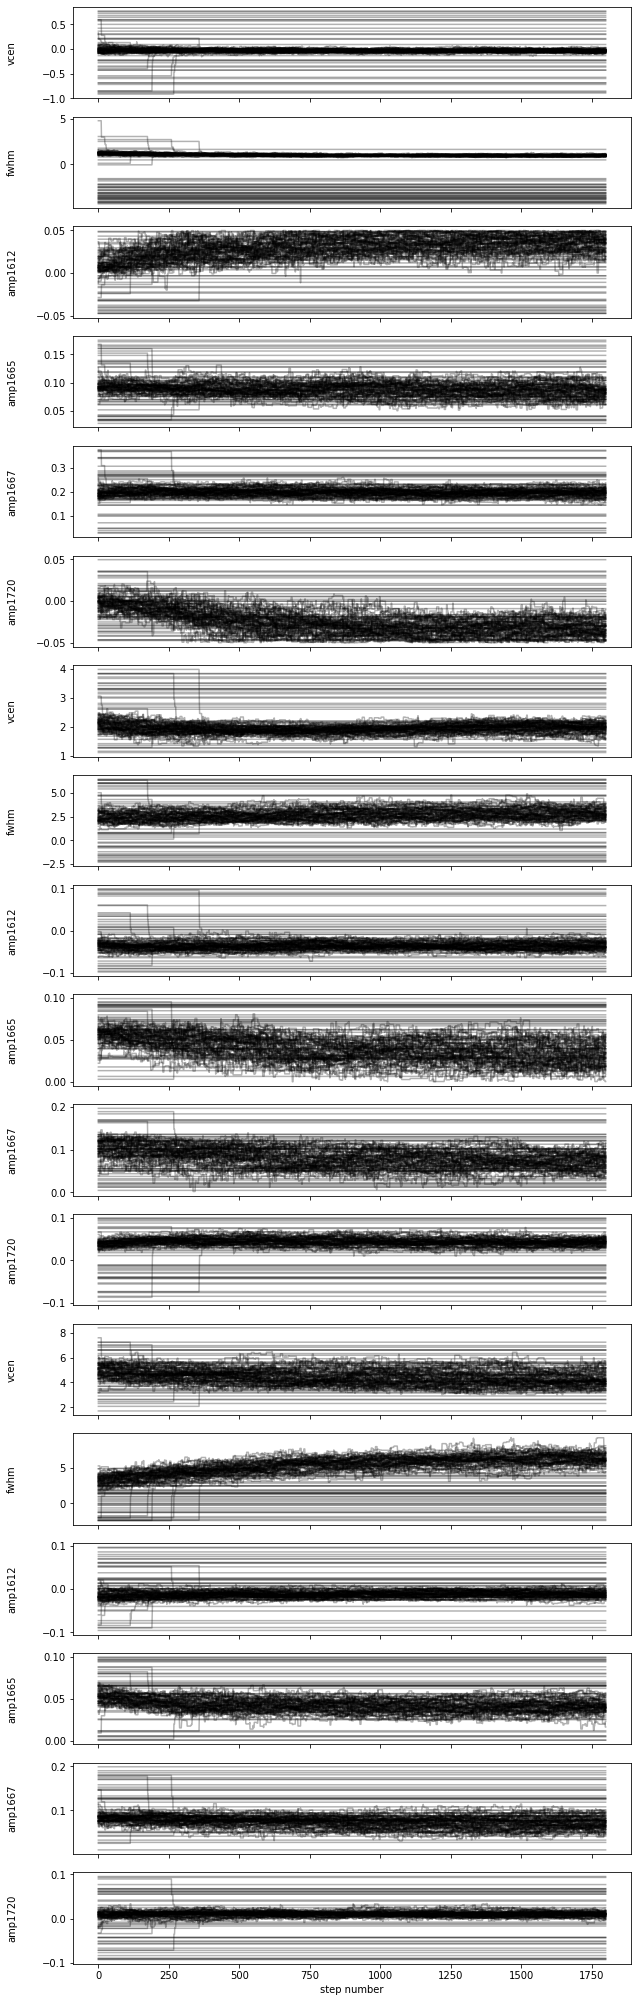

In [19]:
fig, axes = plt.subplots(ndim, figsize=(10, ndim*2), sharex=True)
samples = sampler.get_chain()
labels = []
for i in range(ndim//6):
    labels = labels+["vcen", "fwhm", "amp1612","amp1665", "amp1667", "amp1720"]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[200:,:, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [20]:
np.array(inputpara).flatten()

array([ 0.  ,  1.  ,  0.03,  0.1 ,  0.2 , -0.03,  2.  ,  3.  , -0.04,
        0.05,  0.1 ,  0.04,  5.  ,  5.  , -0.01,  0.03,  0.06,  0.01])

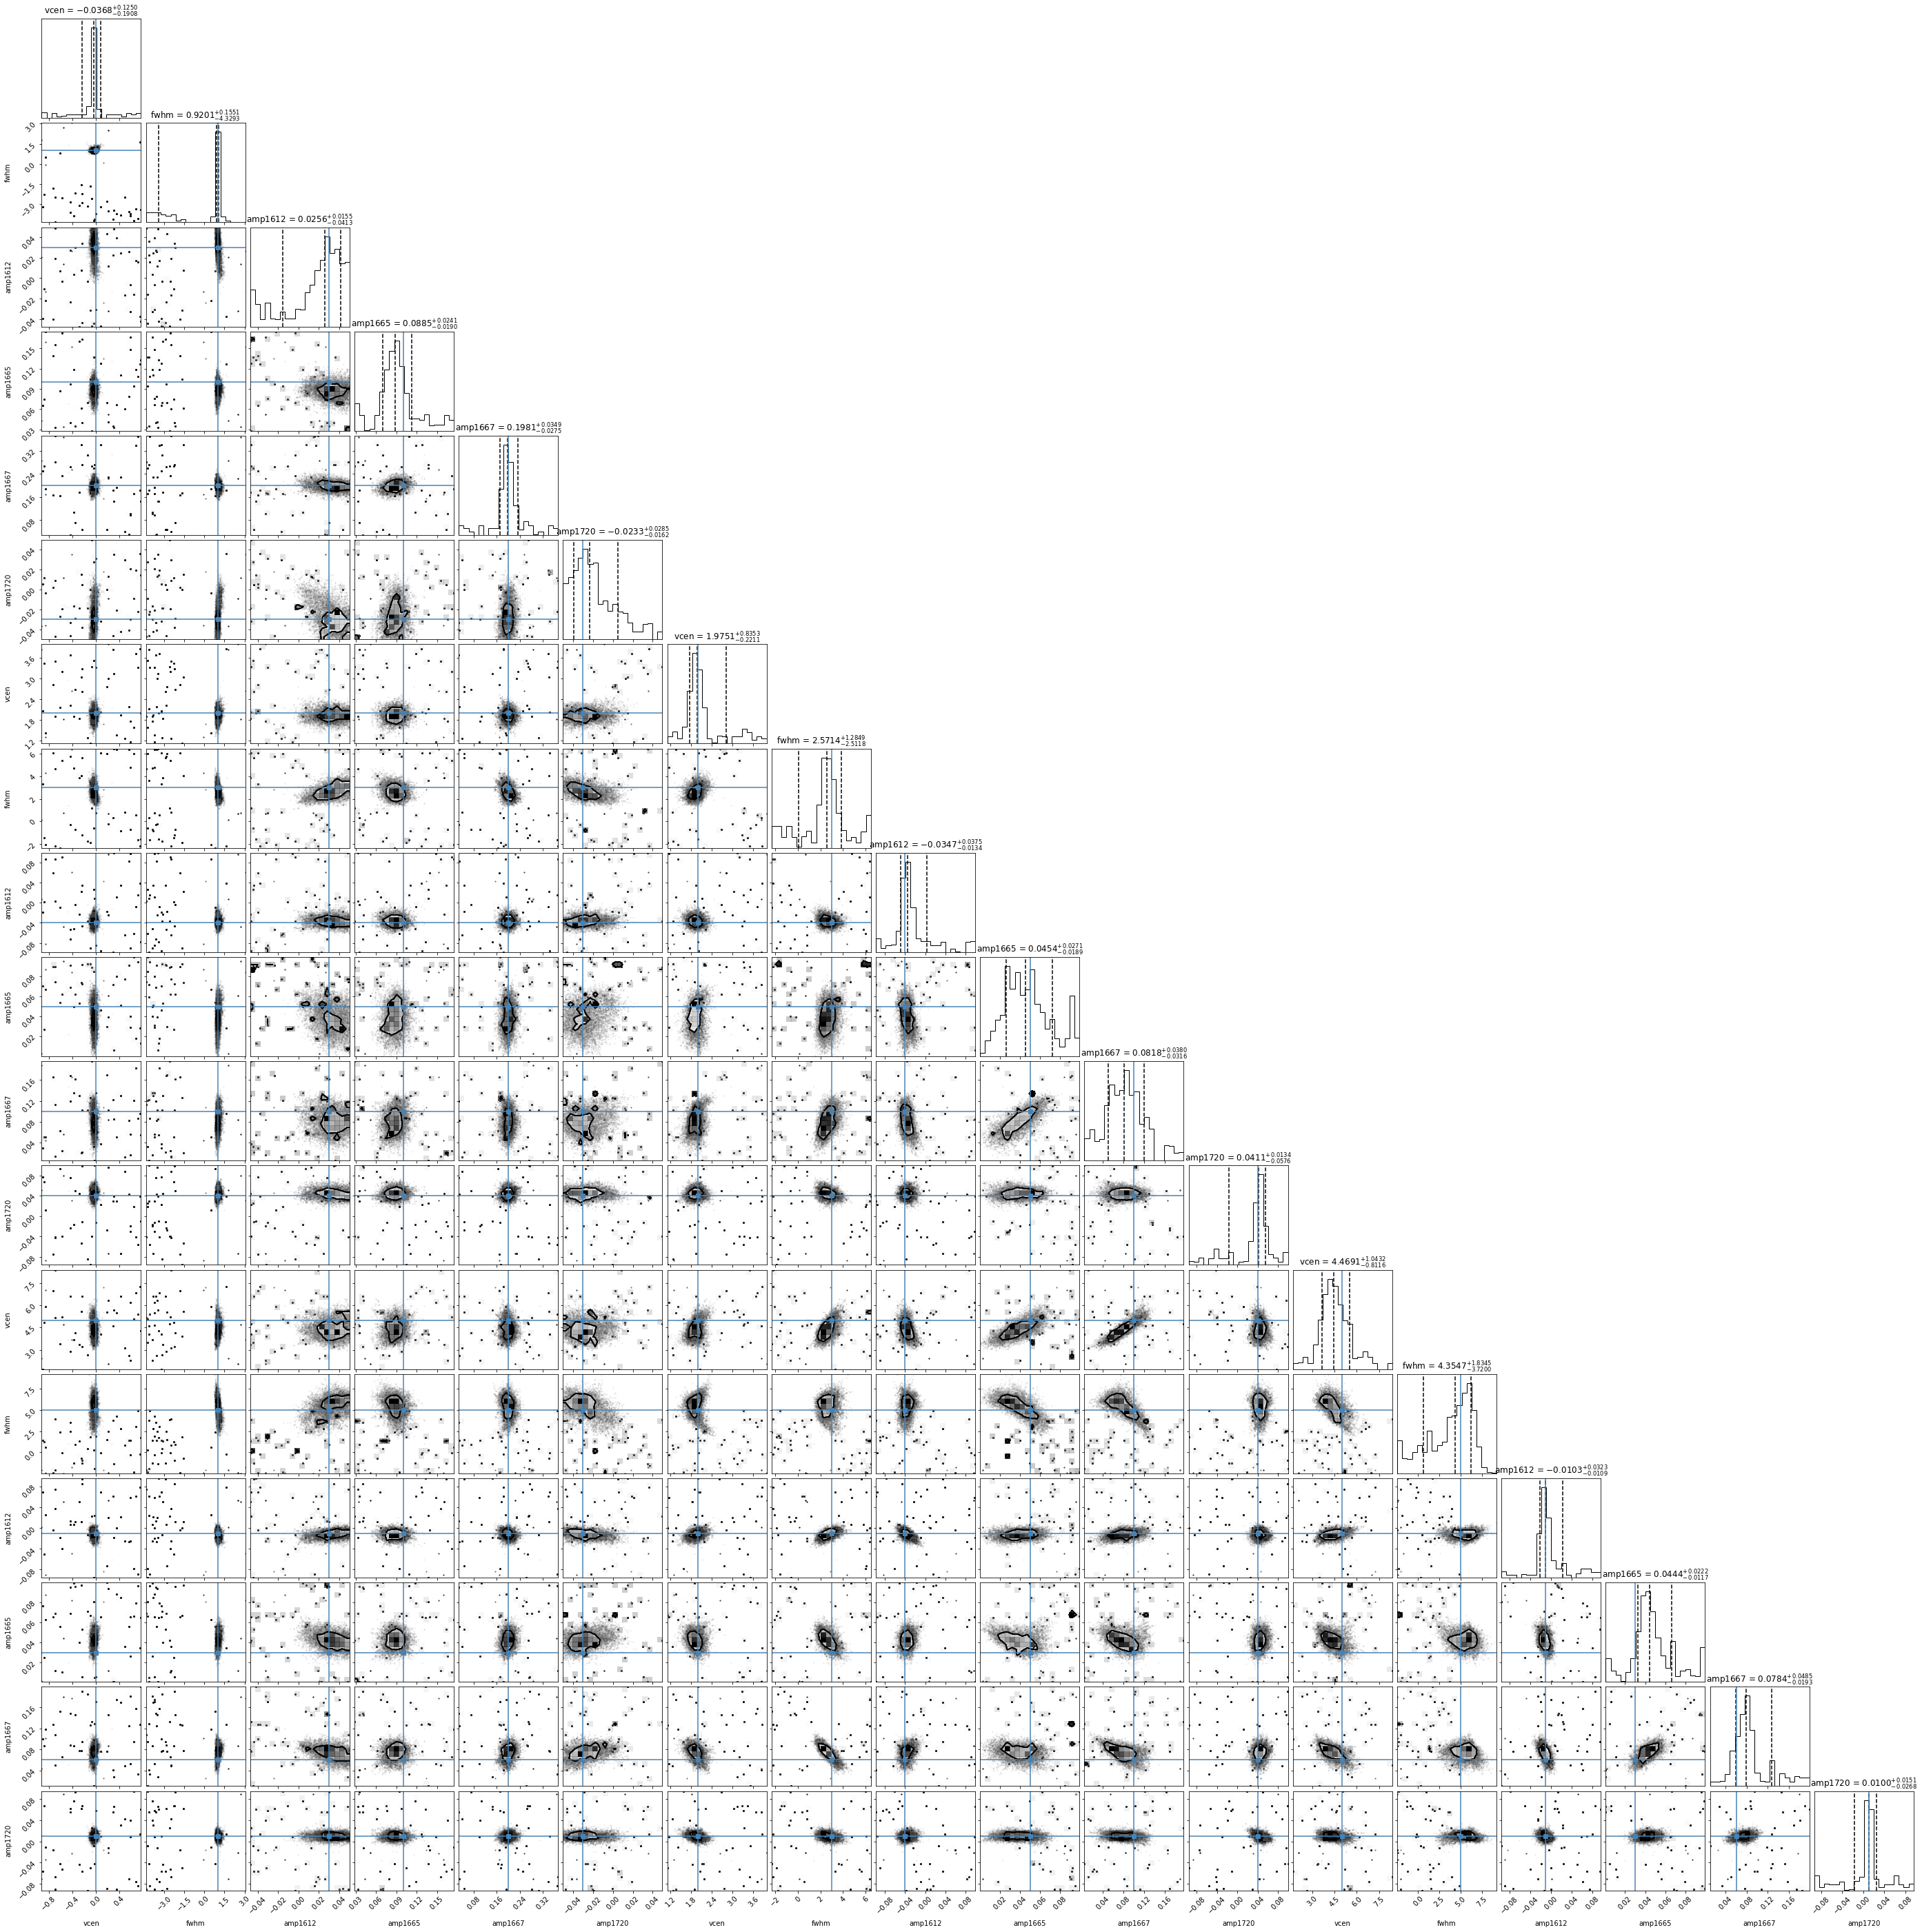

In [21]:
import corner
#fig = corner.corner(flat_samples, labels=labels)
fig = corner.corner(flat_samples, labels=labels,truths=np.array(inputpara).flatten(),quantiles=[0.16,0.5,0.84], levels=[1-np.exp(-0.5),1-np.exp(-0.5),1-np.exp(-0.5),1-np.exp(-0.5),1-np.exp(-0.5)],show_titles=True, title_fmt='.4f')


In [22]:
from IPython.display import display, Math
truths = np.array(inputpara).flatten()

for i in range(ndim):
    mcmc = np.percentile(flat_samples[1000:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}} ; {4:.3f}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i],truths[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

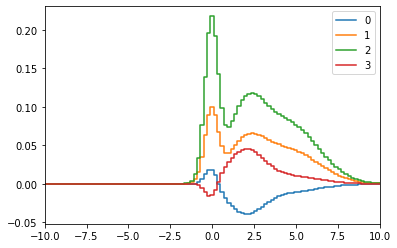

In [23]:
_ = makeobs(v,0.,np.reshape(np.array([np.percentile(flat_samples[:, i], [16,50,84])[1] for i in range(ndim)]),(-1,6)))

In [24]:
log_prob([np.percentile(flat_samples[:, i], [16,50,84])[1] for i in range(ndim)],obs,v,est,plot=True, vmin=-5,vmax=15)

TypeError: log_prob() got multiple values for argument 'plot'